In [1]:
import torch
import torch.nn as nn 

In [13]:
from types import SimpleNamespace
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 1024,
    "emb_dim": 768,
    "out_dim": 768,
    "n_heads": 12, ## Number of heads in a transformer
    "n_layers": 12, ## Number of transformer layers
    "drop_rate": 0.1,
    "qkv_bias": False
}


config = SimpleNamespace(**GPT_CONFIG_124M)

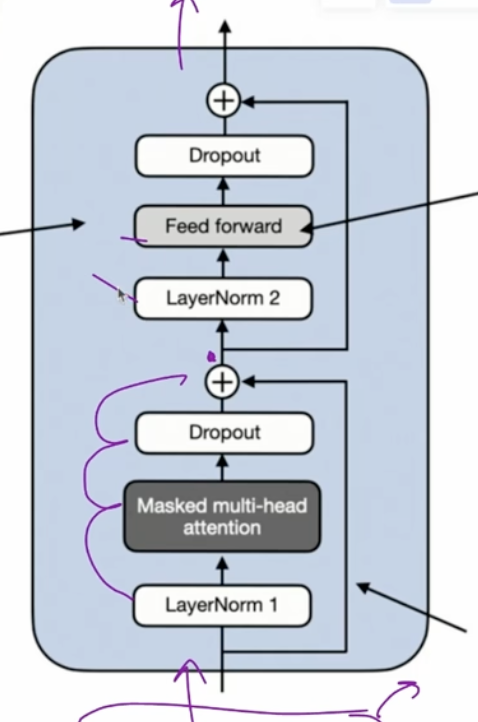

In [22]:

class LayerNorm(nn.Module):
    def __init__(self,emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))
    
    def forward(self,x):
        mean = x.mean(dim=-1,keepdim=True)
        var = x.var(dim=-1,keepdim=True, unbiased=False)
        norm_x = (x-mean)/ torch.sqrt(var+self.eps)
        return self.scale * norm_x + self.shift


class MultiHeadAttention(nn.Module):
    """
    Analyzes relationship between input elements 
    """
    def __init__(self,cfg):
        super().__init__()
        
        self.out_dim = cfg.out_dim
        self.num_heads = cfg.n_heads
        self.per_head_out_dim = self.out_dim//self.num_heads

    
        self.query_matrix = nn.Linear(cfg.emb_dim,cfg.out_dim,bias=cfg.qkv_bias)
        self.key_matrix = nn.Linear(cfg.emb_dim,cfg.out_dim,bias=cfg.qkv_bias)
        self.value_matrix = nn.Linear(cfg.emb_dim,cfg.out_dim,bias=cfg.qkv_bias)

        self.drop_out = nn.Dropout(cfg.drop_rate)
        self.register_buffer("mask",
            torch.triu(torch.ones(cfg.context_length,cfg.context_length),diagonal=1)
        )

        self.out_proj = nn.Linear(self.out_dim, self.out_dim)


    def forward(self,x):
        num_batches, num_input_tokens, emb_dim = x.shape
        
        ### Shape = num_batches * num_input_tokens * out_dim
        queries = self.query_matrix(x)
        keys = self.key_matrix(x)
        values = self.value_matrix(x)


        ### Attention needs to be applied head wise, so split into heads
        queries = queries.view(num_batches, num_input_tokens, self.num_heads, self.per_head_out_dim)
        keys = keys.view(num_batches, num_input_tokens, self.num_heads, self.per_head_out_dim)
        values = values.view(num_batches, num_input_tokens, self.num_heads, self.per_head_out_dim)

        ### Apply transpose to push num_input_tokens , per_head_out to end
        queries = queries.transpose(1,2)
        keys = keys.transpose(1,2)
        values = values.transpose(1,2)

        ### Compute Attention
        #1. Attention Scores
        attn_scores = queries @ keys.transpose(2,3)

        #2. Masking
        mask_bool = self.mask.bool()[:num_input_tokens,:num_input_tokens]
        attn_scores.masked_fill_(mask_bool,-torch.inf)

        #3. Attention Weights
        attn_weights = torch.softmax(attn_scores/keys.shape[-1]**0.5, dim=-1)

        #4. Dropout
        attn_weights=self.drop_out(attn_weights)

        #5. Context Vector
        context_vec = (attn_weights @ values).transpose(1,2)

        #6. Reshape Context Vector back
        context_vec=context_vec.contiguous().view(num_batches,num_input_tokens,self.out_dim)
        context_vec = self.out_proj(context_vec) # optional projection

        return context_vec



class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self,x):
        return 0.5 * x * (

            1 + torch.tanh(
                torch.sqrt(torch.tensor(2.0/torch.pi)) * 
                (x+0.044715 * torch.pow(x,3))
            )
        )

class FeedForwardNN(nn.Module):
    """
    Handles each token independently unlike attention
    """
    def __init__(self,cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg.emb_dim, 4*cfg.emb_dim), ## Expansion
            GELU(),
            nn.Linear(4*cfg.emb_dim,cfg.emb_dim),  ## Contraction
        )
    
    def forward(self,x):
        return self.layers(x)


class Transformer(nn.Module):
    def __init__(self,cfg):
        super().__init__()

        ## Layer Normalization
        # These are called pre-LayerNorm layers as they are applied before attention and feedforward pass
        # Older version used to have pro_LayerNorm but that is found to have wrose training dynamics
        self.layer_norm1 = LayerNorm(cfg.emb_dim)
        self.layer_norm2 = LayerNorm(cfg.emb_dim)

        ## Mulit Head Attention
        self.multi_head_attention = MultiHeadAttention(cfg)

        ## FeedForward Neural Network
        self.feed_forward_nn = FeedForwardNN(cfg) 

        ## Dropout 
        self.drop_shortcut = nn.Dropout(cfg.drop_rate)
    

    def forward(self,x):

        # Shortcut connection for attention block
        shortcut = x
        x = self.layer_norm1(x)
        x = self.multi_head_attention(x) # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x= x+shortcut # Add the original input back

        # Shortcut connection for feed forward block
        shortcut = x
        x = self.layer_norm2(x)
        x = self.feed_forward_nn(x)
        x = self.drop_shortcut(x)
        x = x+shortcut # Add the original input back

        return x


In [24]:
torch.manual_seed(123)

x = torch.rand(2,4,768)
block = Transformer(config)
output = block(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)


Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])


<div class="alert alert-block alert-warning">
    
The preservation of shape throughout the transformer block architecture is not incidental
but a crucial aspect of its design. 

This design enables its effective application across a wide
range of sequence-to-sequence tasks, where each output vector directly corresponds to an
input vector, maintaining a one-to-one relationship. 
</div>

<div class="alert alert-block alert-warning">

However, the output is a context vector
that encapsulates information from the entire input sequence.

This means that while the physical dimensions of the sequence (length and feature size)
remain unchanged as it passes through the transformer block, the content of each output
vector is re-encoded to integrate contextual information from across the entire input
sequence.

</div>